In [ ]:
"""
Tonality Distribution Analysis (ACE/LAB Version)
=================================================

This script walks through the dataset directory, reads every `.lab` file
contained in the **lastfm**, **suno**, and **udio** collections, estimates
each song's **tonality/key** from the chord progression, and visualises the
results with a **grouped bar chart** so you can compare tendencies among the
three collections.

Key estimation is done by analyzing chord root frequencies weighted by duration,
with major/minor quality influencing the final mode determination.

*Tonality rows are sorted from highest to lowest using **lastfm** counts as the
reference.*
"""
from __future__ import annotations

import glob
import json
import os
from collections import Counter, defaultdict
from typing import Dict, List, Set, Tuple

from tqdm import tqdm

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# Fallback `display` so the script works outside IPython
# ---------------------------------------------------------------------------
try:
    from IPython.display import display  # type: ignore
except ImportError:  # Running outside Jupyter

    def display(obj):  # type: ignore  # noqa: D401, ANN001
        """Plain‑text fallback when rich display is unavailable."""

        print(obj)

# ---------------------------------------------------------------------------
# Configuration – change BASE_DIR if your data lives elsewhere
# ---------------------------------------------------------------------------
BASE_DIR: str = "/workspace/dataset"
COLLECTIONS: List[str] = ["lastfm", "suno", "udio"]
COLORS: List[str] = ["#51BFFF", "#FFC400", "#FF5B0E"]  # Colour palette

In [4]:
# ---------------------------------------------------------------------------
# LAB File Parsing and Key Estimation
# ---------------------------------------------------------------------------

# Pitch class mapping (for enharmonic equivalence)
NOTE_TO_PC = {
    'C': 0, 'C#': 1, 'Db': 1, 'D': 2, 'D#': 3, 'Eb': 3,
    'E': 4, 'Fb': 4, 'E#': 5, 'F': 5, 'F#': 6, 'Gb': 6,
    'G': 7, 'G#': 8, 'Ab': 8, 'A': 9, 'A#': 10, 'Bb': 10,
    'B': 11, 'Cb': 11, 'B#': 0
}

PC_TO_NOTE = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

# Krumhansl-Kessler key profiles (correlation weights)
MAJOR_PROFILE = np.array([6.35, 2.23, 3.48, 2.33, 4.38, 4.09, 2.52, 5.19, 2.39, 3.66, 2.29, 2.88])
MINOR_PROFILE = np.array([6.33, 2.68, 3.52, 5.38, 2.60, 3.53, 2.54, 4.75, 3.98, 2.69, 3.34, 3.17])


def parse_root(chord_label: str) -> Tuple[str, str, int] | None:
    """
    Parse chord label to extract root note, quality, and pitch class.
    
    Format: Root:quality[/bass] (e.g., D:min7, G:7, A#:maj, F#:maj/5)
    
    Returns:
        (root_name, quality, pitch_class) or None if unparseable
    """
    if chord_label == 'N' or not chord_label:
        return None
    
    # Remove bass note if present
    if '/' in chord_label:
        chord_label = chord_label.split('/')[0]
    
    if ':' in chord_label:
        parts = chord_label.split(':', 1)
        root = parts[0]
        quality = parts[1] if len(parts) > 1 else 'maj'
    else:
        root = chord_label
        quality = 'maj'
    
    # Handle enharmonic spellings
    root_upper = root.replace('b', 'b').replace('#', '#')
    
    if root_upper in NOTE_TO_PC:
        pc = NOTE_TO_PC[root_upper]
        return root, quality, pc
    
    return None


def is_minor_quality(quality: str) -> bool:
    """Check if chord quality suggests minor tonality."""
    minor_indicators = ['min', 'dim', 'hdim']
    quality_lower = quality.lower()
    return any(ind in quality_lower for ind in minor_indicators)


def is_major_quality(quality: str) -> bool:
    """Check if chord quality suggests major tonality."""
    # Dominant 7 and major chords suggest major key context
    if is_minor_quality(quality):
        return False
    major_indicators = ['maj', '7', 'sus', '(1']
    quality_lower = quality.lower()
    return any(ind in quality_lower for ind in major_indicators) or quality == ''


def parse_lab_file(lab_path: str) -> List[Tuple[float, float, str, str, int]]:
    """
    Parse a .lab file and extract chord information with timing.
    
    Returns:
        List of (start_time, end_time, root, quality, pitch_class) tuples
    """
    if not os.path.exists(lab_path):
        return []
    
    chords = []
    try:
        with open(lab_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                
                parts = line.split()
                if len(parts) >= 3:
                    start_time = float(parts[0])
                    end_time = float(parts[1])
                    chord_label = parts[2]
                    
                    parsed = parse_root(chord_label)
                    if parsed:
                        root, quality, pc = parsed
                        chords.append((start_time, end_time, root, quality, pc))
    except Exception as e:
        pass
    
    return chords


def estimate_key_from_chords(chords: List[Tuple[float, float, str, str, int]]) -> str | None:
    """
    Estimate the key of a song from its chord progression using
    duration-weighted pitch class distribution and Krumhansl-Kessler profiles.
    
    Returns:
        Key string like 'C major', 'A minor', or None if undetermined
    """
    if not chords:
        return None
    
    # Build pitch class histogram weighted by duration
    pc_weights = np.zeros(12)
    major_weight = 0
    minor_weight = 0
    
    for start, end, root, quality, pc in chords:
        duration = max(0, end - start)
        pc_weights[pc] += duration
        
        # Track major vs minor tendency
        if is_major_quality(quality):
            major_weight += duration
        elif is_minor_quality(quality):
            minor_weight += duration
    
    # Normalize
    total = pc_weights.sum()
    if total == 0:
        return None
    pc_weights /= total
    
    # Correlate with all major and minor key profiles
    best_key = None
    best_corr = -1
    
    for root_pc in range(12):
        # Rotate the pitch class weights to align with key
        rotated = np.roll(pc_weights, -root_pc)
        
        # Correlation with major profile
        major_corr = np.corrcoef(rotated, MAJOR_PROFILE)[0, 1]
        if major_corr > best_corr:
            best_corr = major_corr
            best_key = f"{PC_TO_NOTE[root_pc]} major"
        
        # Correlation with minor profile
        minor_corr = np.corrcoef(rotated, MINOR_PROFILE)[0, 1]
        if minor_corr > best_corr:
            best_corr = minor_corr
            best_key = f"{PC_TO_NOTE[root_pc]} minor"
    
    # Use chord quality as a tie-breaker for ambiguous cases
    # (helps distinguish relative major/minor)
    if best_key and (major_weight > 0 or minor_weight > 0):
        root_note = best_key.split()[0]
        mode = best_key.split()[1]
        
        # If chord qualities strongly suggest opposite mode, adjust
        quality_ratio = minor_weight / (major_weight + minor_weight + 0.001)
        if mode == 'major' and quality_ratio > 0.6:
            # Likely relative minor
            relative_minor_pc = (NOTE_TO_PC[root_note] + 9) % 12
            best_key = f"{PC_TO_NOTE[relative_minor_pc]} minor"
        elif mode == 'minor' and quality_ratio < 0.3:
            # Likely relative major
            relative_major_pc = (NOTE_TO_PC[root_note] + 3) % 12
            best_key = f"{PC_TO_NOTE[relative_major_pc]} major"
    
    return best_key

In [5]:
# ---------------------------------------------------------------------------
# Helper functions for scanning and building dataframes
# ---------------------------------------------------------------------------

def dominant_genre(genre_dict: Dict[str, str]) -> str:
    """Return the genre key with the highest score (float cast)."""
    return max(genre_dict.items(), key=lambda kv: float(kv[1]))[0]


def scan_collections_ace(
    base_dir: str = BASE_DIR, collections: List[str] = COLLECTIONS
):
    """
    Walk each collection, reading .lab files to estimate tonality.
    Also reads style JSON if available for genre analysis.
    """
    tonality_counts: Dict[str, Counter] = defaultdict(Counter)
    tonality_by_style: Dict[str, Counter] = defaultdict(Counter)

    for collection in tqdm(collections, desc="Collections"):
        collection_path = os.path.join(base_dir, collection)
        
        if not os.path.exists(collection_path):
            print(f"Warning: {collection_path} does not exist")
            continue
        
        # Find all song directories
        song_dirs = [d for d in os.listdir(collection_path) 
                     if os.path.isdir(os.path.join(collection_path, d))]
        
        for song_id in tqdm(song_dirs, desc=f"  {collection}", leave=False):
            song_path = os.path.join(collection_path, song_id)
            lab_file = os.path.join(song_path, f"{song_id}.lab")
            
            if not os.path.exists(lab_file):
                continue
            
            # Parse LAB file and estimate key
            chords = parse_lab_file(lab_file)
            tonality = estimate_key_from_chords(chords)
            
            if tonality:
                tonality_counts[collection][tonality] += 1
                
                # Also check for style information
                style_path = os.path.join(song_path, f"{song_id}_style.json")
                style = "unknown"
                if os.path.isfile(style_path):
                    try:
                        with open(style_path, "r", encoding="utf-8") as sf:
                            style_data = json.load(sf)
                        genre_dict = style_data.get("genre_dortmund", {})
                        if genre_dict:
                            style = dominant_genre(genre_dict)
                    except Exception:
                        pass
                
                tonality_by_style[style][tonality] += 1

    return tonality_counts, tonality_by_style


def build_dataframe(
    tonality_counts: Dict[str, Counter], collections: List[str] = COLLECTIONS
) -> pd.DataFrame:
    """Convert nested counters into a tidy DataFrame (tonality × collection)."""

    all_tonalities = sorted({t for counter in tonality_counts.values() for t in counter})
    df = pd.DataFrame(index=all_tonalities, columns=collections).fillna(0)

    for collection, counter in tonality_counts.items():
        for tonality, count in counter.items():
            df.loc[tonality, collection] = count

    return df.astype(int)


def build_style_dataframe(tonality_by_style: Dict[str, Counter]) -> pd.DataFrame:
    """Convert tonality‑by‑style counters into DataFrame (tonality × style)."""

    if not tonality_by_style:
        return pd.DataFrame()

    all_tonalities = sorted({t for c in tonality_by_style.values() for t in c})
    styles = sorted(tonality_by_style.keys())
    df_style = pd.DataFrame(index=all_tonalities, columns=styles).fillna(0)
    for style, counter in tonality_by_style.items():
        for tonality, count in counter.items():
            df_style.loc[tonality, style] = count
    return df_style.astype(int)

In [ ]:
# 1. Scan LAB files and estimate keys
tonality_counts, tonality_by_style = scan_collections_ace()

Collections:   0%|          | 0/3 [00:00<?, ?it/s]

Collections:  33%|███▎      | 1/3 [00:48<01:37, 48.55s/it]

In [ ]:
# Preview tonality counts
tonality_counts

defaultdict(collections.Counter,
            {'lastfm': Counter({'G major': 1991,
                      'C major': 1823,
                      'F major': 1649,
                      'D major': 1606,
                      'A# major': 1179,
                      'E major': 1016,
                      'D# major': 978,
                      'A major': 955,
                      'E minor': 939,
                      'A minor': 921,
                      'D minor': 719,
                      'C# major': 669,
                      'G# major': 663,
                      'B major': 603,
                      'F# major': 584,
                      'B minor': 549,
                      'C minor': 448,
                      'G minor': 366,
                      'F minor': 336,
                      'C# minor': 245,
                      'F# minor': 232,
                      'A# minor': 166,
                      'G# minor': 151,
                      'D# minor': 128}),
             'suno': Counte

Tonalities × Collections matrix (sorted by lastfm):


,lastfm,suno,udio
G major,1991,1710,1740
C major,1823,1634,1741
F major,1649,1007,1420
D major,1606,1449,1194
A# major,1179,519,1150
E major,1016,1382,980
D# major,978,705,942
A major,955,1155,941
E minor,939,1268,916
A minor,921,841,962


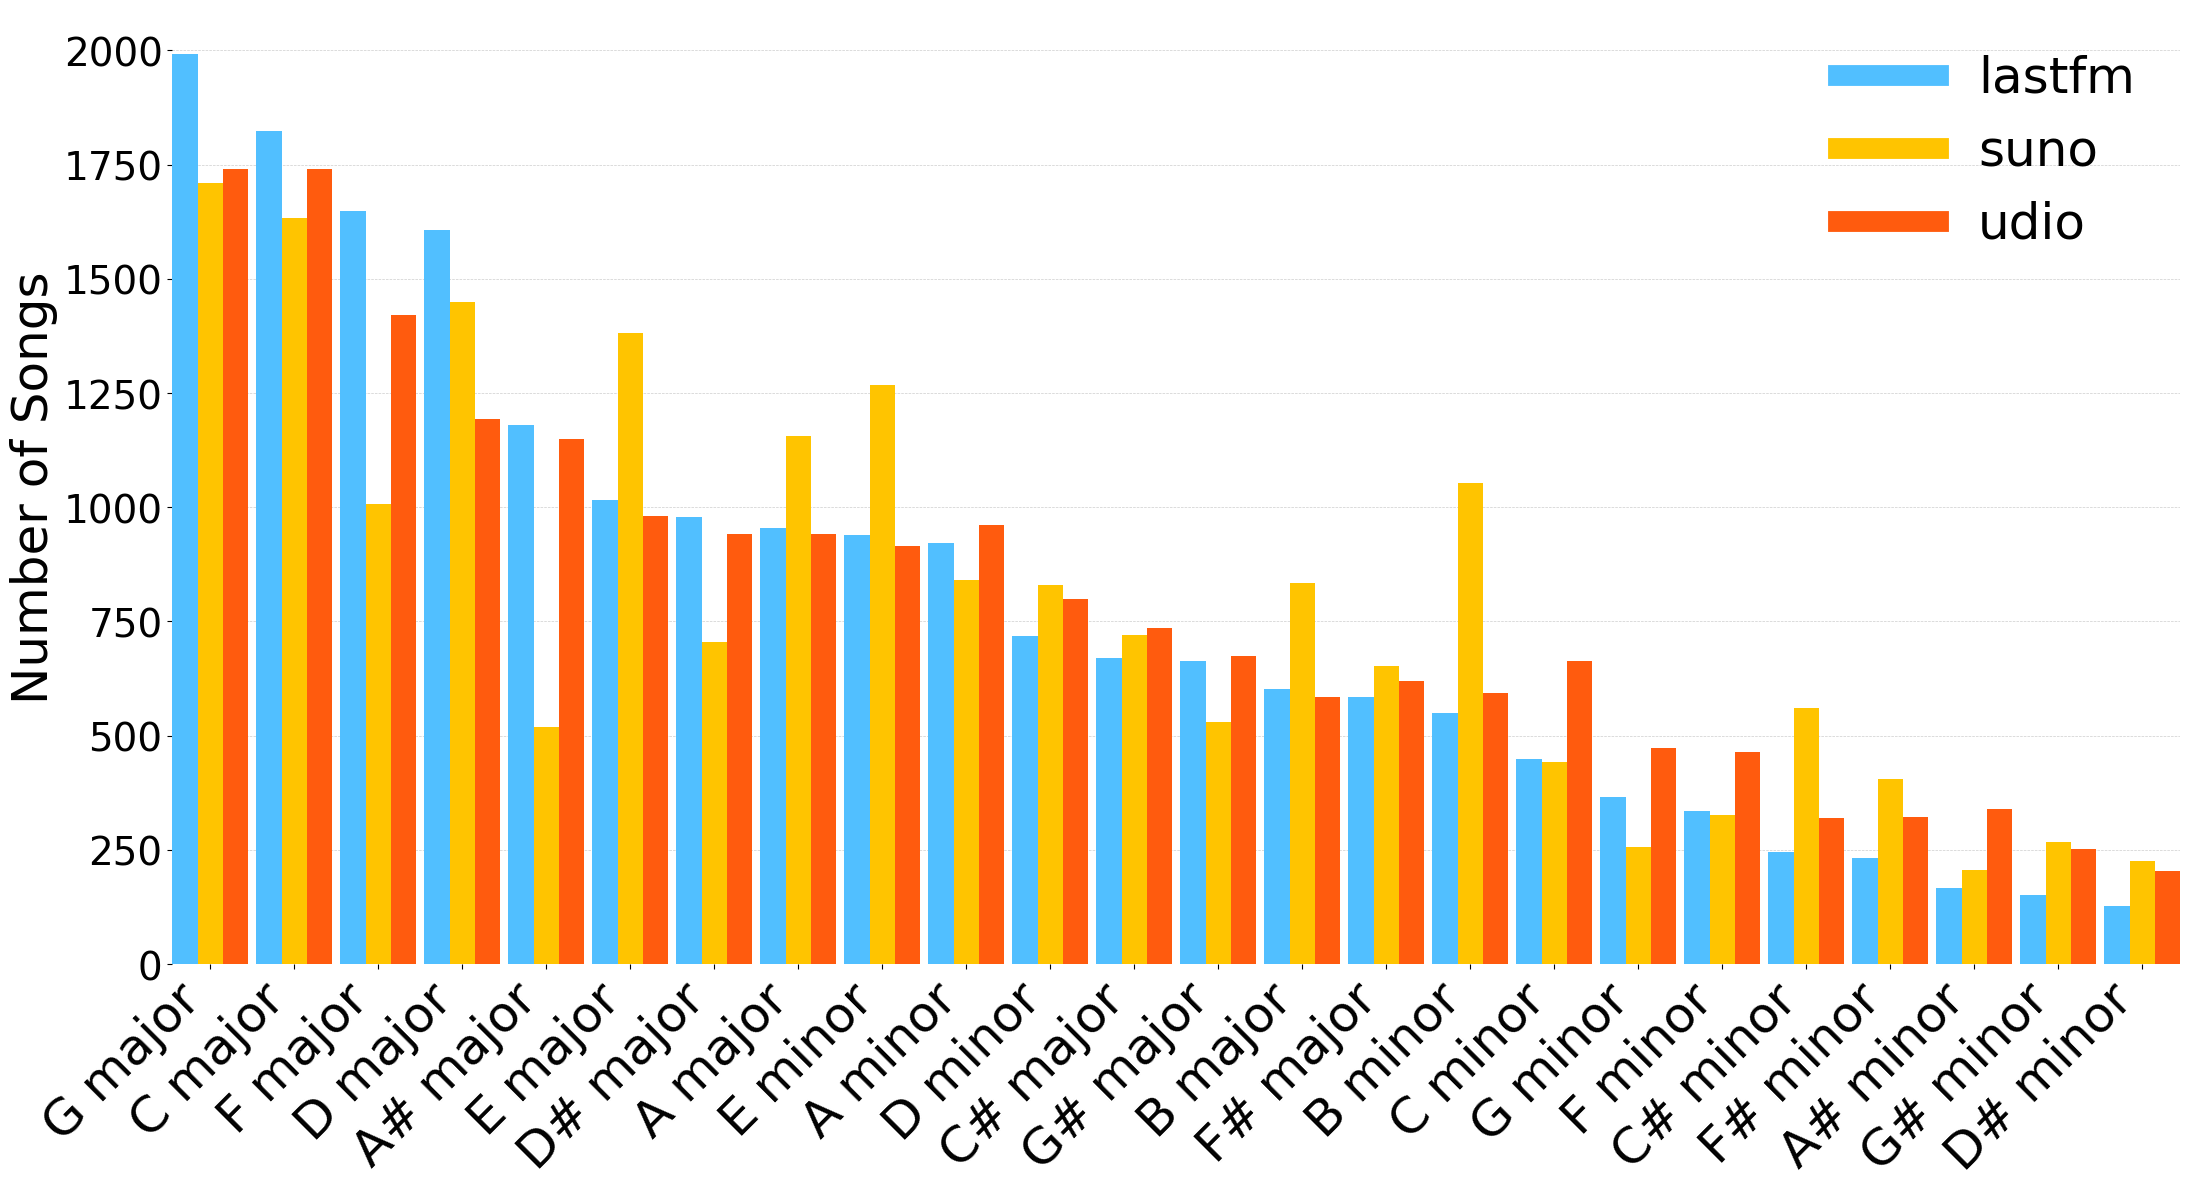

In [ ]:
from matplotlib.lines import Line2D

# ---------------------------------------------------------------------------
# 2. Build tonality × collection matrix
df = build_dataframe(tonality_counts)

# 2a. Sort tonalities by **lastfm** counts (descending)
if "lastfm" in df.columns:
    df = df.sort_values(by="lastfm", ascending=False)

print("Tonalities × Collections matrix (sorted by lastfm):")
display(df)

# 3. Grouped bar chart — styling matches chord quality figure
x = np.arange(len(df.index))
bar_width = 0.9 / len(COLLECTIONS)
text_size = 28
legend_size = 28

fig, ax = plt.subplots(figsize=(22, 12))

for idx, (col, color) in enumerate(zip(COLLECTIONS, COLORS)):
    offsets = (idx - (len(COLLECTIONS) - 1) / 2) * bar_width
    positions = x + offsets
    ax.bar(
        positions,
        df[col],
        width=bar_width,
        color=color,
        label=col,
        alpha=1.0,
    )

ax.set_axisbelow(True)
ax.grid(axis='y',
        linestyle='--',
        linewidth=0.5,
        color="#cdcdcd",
        alpha=1.0)

ax.margins(x=0)

ax.set_xticks(x)
ax.tick_params(axis="y", labelsize=20)
ax.set_xticklabels(df.index, rotation=45, ha="right", fontsize=text_size, fontweight='normal')
ax.set_xlabel("Tonality", fontsize=text_size, fontweight='normal')
ax.set_ylabel("Number of Songs", fontsize=text_size, fontweight='normal')

for spine in ax.spines.values():
    spine.set_visible(False)

ax.legend([Line2D([0], [0], color=c, lw=15) for c in COLORS], COLLECTIONS,
          fontsize=legend_size, loc="upper right", frameon=False)

plt.tight_layout()
plt.savefig("../Figures/tonalities_per_collection.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# ---------------------------------------------------------------------------
# 4. Smaller grouped bar chart (same data, different styling)
# ---------------------------------------------------------------------------
x = np.arange(len(df))
bar_width = 0.9 / len(COLLECTIONS)

fig, ax = plt.subplots(figsize=(14, 6))
for idx, (col, color) in enumerate(zip(COLLECTIONS, COLORS)):
    positions = x + (idx - (len(COLLECTIONS) - 1) / 2) * bar_width
    ax.bar(positions, df[col], width=bar_width, color=color, label=col, alpha=0.9)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.margins(x=0)
ax.set_xticks(x)
ax.set_xticklabels(df.index, rotation=45, ha="right")
ax.set_xlabel("Tonality (Estimated Key)")
ax.set_ylabel("Number of Songs")
ax.tick_params(axis="y", labelsize=12)
ax.set_title("")
ax.legend(fontsize=10, loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

NameError: name 'np' is not defined

Style analysis: udio: 100%|██████████| 19992/19992 [00:43<00:00, 461.08it/s]
/tmp/ipykernel_372471/2351639167.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("cividis", len(all_tones))  # blue→orange gradient


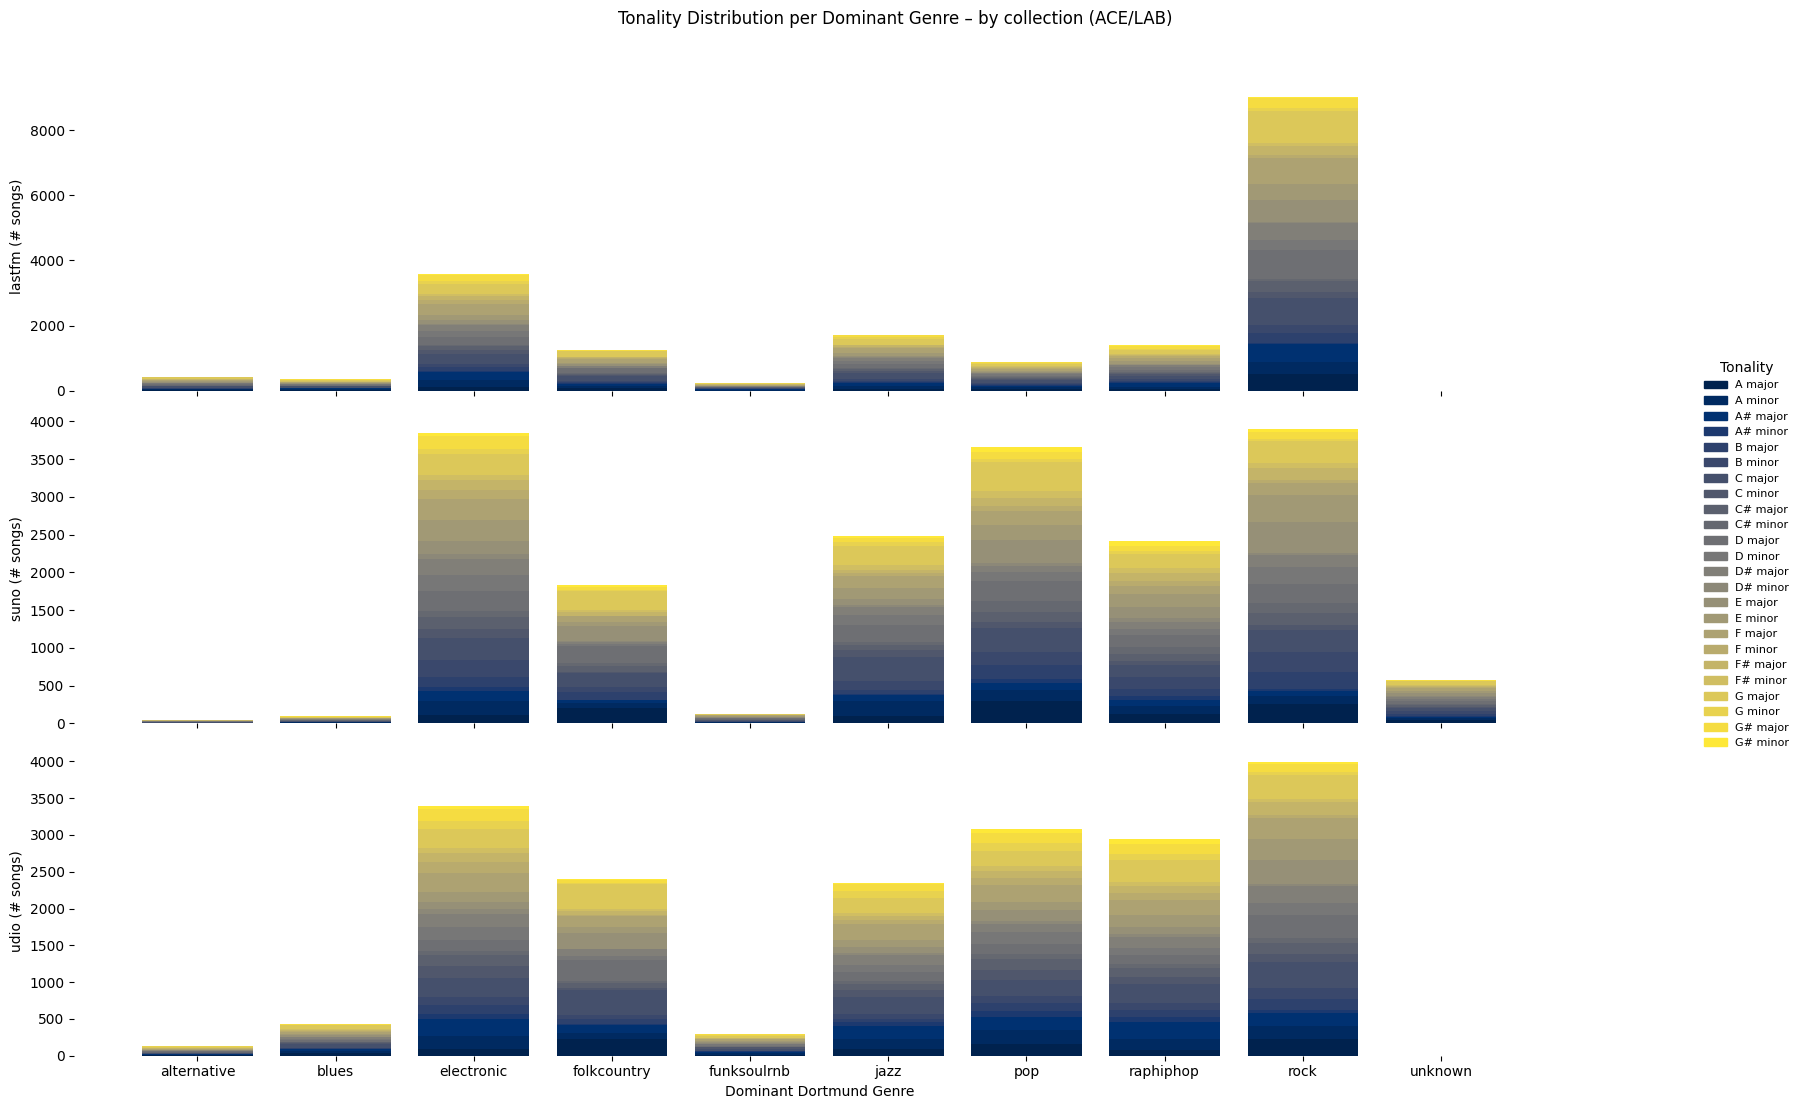

In [ ]:
# ---------------------------------------------------------------------------
# 5. Tonality distribution per dominant Dortmund genre (stacked bar)
# ---------------------------------------------------------------------------
if tonality_by_style:
    # Build nested counters: collection × style × tonality
    style_coll_ton: Dict[str, Dict[str, Counter]] = defaultdict(lambda: defaultdict(Counter))
    
    for collection in COLLECTIONS:
        collection_path = os.path.join(BASE_DIR, collection)
        if not os.path.exists(collection_path):
            continue
            
        song_dirs = [d for d in os.listdir(collection_path) 
                     if os.path.isdir(os.path.join(collection_path, d))]
        
        for song_id in tqdm(song_dirs, desc=f"Style analysis: {collection}"):
            song_path = os.path.join(collection_path, song_id)
            lab_file = os.path.join(song_path, f"{song_id}.lab")
            
            if not os.path.exists(lab_file):
                continue
            
            chords = parse_lab_file(lab_file)
            ton = estimate_key_from_chords(chords)
            if not ton:
                continue

            style_path = os.path.join(song_path, f"{song_id}_style.json")
            style = "unknown"
            if os.path.isfile(style_path):
                try:
                    with open(style_path, "r", encoding="utf-8") as sf:
                        gdict = json.load(sf).get("genre_dortmund", {})
                    style = dominant_genre(gdict) if gdict else "unknown"
                except Exception:
                    pass

            style_coll_ton[collection][style][ton] += 1

    # Lists & colours
    styles = sorted({s for coll in style_coll_ton.values() for s in coll})
    present_colls = [c for c in COLLECTIONS if c in style_coll_ton]
    all_tones = sorted({t for coll in style_coll_ton.values() for sty in coll.values() for t in sty})

    cmap = plt.cm.get_cmap("cividis", len(all_tones))  # blue→orange gradient
    tone_colors = {tone: cmap(i) for i, tone in enumerate(all_tones)}

    # Plot rows per collection
    fig, axes = plt.subplots(
        nrows=len(present_colls), figsize=(18, 4 * len(present_colls)), sharex=True
    )
    if len(present_colls) == 1:
        axes = [axes]

    for ax, coll in zip(axes, present_colls):
        df_coll = pd.DataFrame(index=styles, columns=all_tones).fillna(0).astype(float)
        for sty in styles:
            counter = style_coll_ton[coll].get(sty, Counter())
            for ton, cnt in counter.items():
                df_coll.at[sty, ton] = float(cnt)

        bottom = np.zeros(len(styles), dtype=float)
        for tone in all_tones:
            values = df_coll[tone].to_numpy().astype(float)
            ax.bar(styles, values, bottom=bottom, color=tone_colors[tone], edgecolor="none")
            bottom += values

        ax.set_ylabel(f"{coll} (# songs)")
        for spine in ax.spines.values():
            spine.set_visible(False)

    axes[-1].set_xlabel("Dominant Dortmund Genre")
    fig.suptitle("Tonality Distribution per Dominant Genre – by collection (ACE/LAB)", y=0.92)
    fig.tight_layout(rect=[0, 0, 0.88, 0.9])

    handles = [plt.Rectangle((0, 0), 1, 1, color=tone_colors[t]) for t in all_tones]
    fig.legend(handles, all_tones, title="Tonality", loc="center right", frameon=False, ncol=1, fontsize=8)

    plt.show()
else:
    print("No style information available for genre-based analysis.")

In [ ]:
# ---------------------------------------------------------------------------
# 6. Summary statistics
# ---------------------------------------------------------------------------
print("\n" + "="*60)
print("SUMMARY STATISTICS (ACE/LAB Key Estimation)")
print("="*60)

for collection in COLLECTIONS:
    if collection in tonality_counts:
        counter = tonality_counts[collection]
        total = sum(counter.values())
        unique_keys = len(counter)
        most_common = counter.most_common(5)
        
        print(f"\n{collection.upper()}:")
        print(f"  Total songs with estimated key: {total}")
        print(f"  Unique keys found: {unique_keys}")
        print(f"  Top 5 keys:")
        for key, count in most_common:
            pct = 100 * count / total if total > 0 else 0
            print(f"    {key}: {count} ({pct:.1f}%)")


SUMMARY STATISTICS (ACE/LAB Key Estimation)

LASTFM:
  Total songs with estimated key: 18916
  Unique keys found: 24
  Top 5 keys:
    G major: 1991 (10.5%)
    C major: 1823 (9.6%)
    F major: 1649 (8.7%)
    D major: 1606 (8.5%)
    A# major: 1179 (6.2%)

SUNO:
  Total songs with estimated key: 18979
  Unique keys found: 24
  Top 5 keys:
    G major: 1710 (9.0%)
    C major: 1634 (8.6%)
    D major: 1449 (7.6%)
    E major: 1382 (7.3%)
    E minor: 1268 (6.7%)

UDIO:
  Total songs with estimated key: 19031
  Unique keys found: 24
  Top 5 keys:
    C major: 1741 (9.1%)
    G major: 1740 (9.1%)
    F major: 1420 (7.5%)
    D major: 1194 (6.3%)
    A# major: 1150 (6.0%)
